In [1]:
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Masquer la fenêtre principale Tkinter
root = Tk()
root.withdraw()

# Forcer la fenêtre à être au premier plan
root.attributes('-topmost', True)
root.update()

# Ouvrir la fenêtre de sélection
fichier = filedialog.askopenfilename(
    title="Choisissez le fichier à analyser",
    filetypes=[("Fichiers CSV", "*.csv"), ("Fichiers Excel", "*.xlsx *.xls"), ("Tous les fichiers", "*.*")]
)

# Lecture du fichier sélectionné avec pandas
df = pd.read_csv(fichier)

C:\Users\pc\AppData\Local\Temp\ipykernel_17452\470342063.py:21: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fichier)


### CONDITIONS MÉTÉO & ENVIRONNEMENT

### Sévérité des accidents selon la météo (BOXPLOT)

Question: Certaines conditions météo rendent-elles les accidents plus graves ?

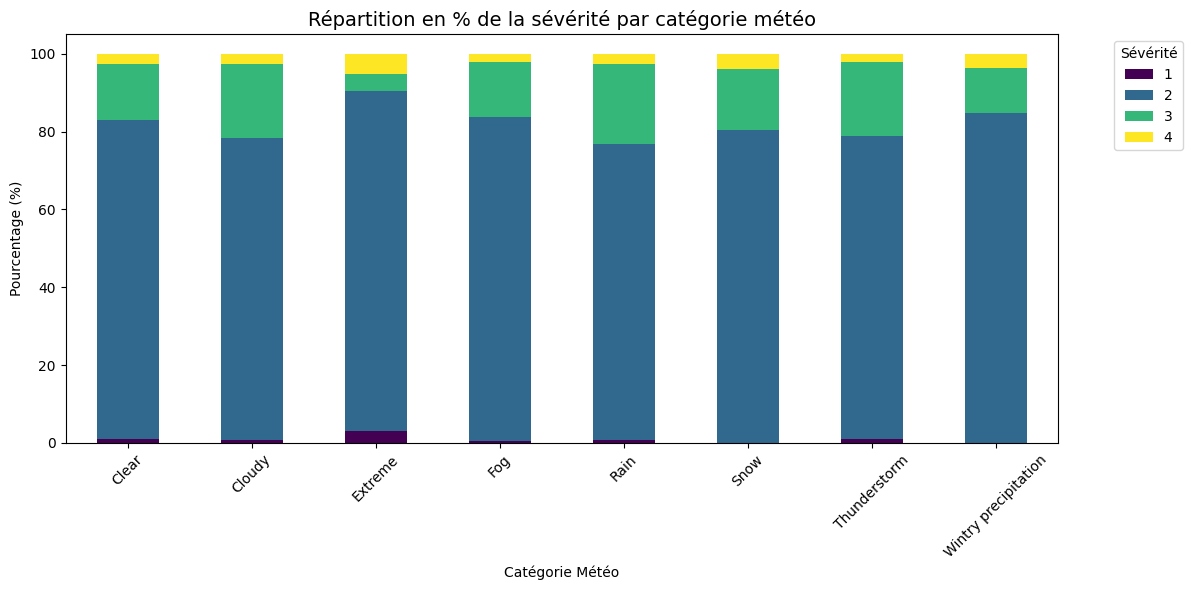

In [ ]:
df_filtered = df[df['Weather_Category'] != 'Unknown'].copy()

# Créer une table de contingence (Météo vs Sévérité)
# On normalise sur l'index (Weather_Category) pour avoir des pourcentages par ligne
ct = pd.crosstab(df_filtered['Weather_Category'], df_filtered['Severity'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

plt.title("Répartition en % de la sévérité par catégorie météo", fontsize=14)
plt.ylabel("Pourcentage (%)")
plt.xlabel("Catégorie Météo")
plt.legend(title="Sévérité", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visibilité vs Sévérité (SCATTER PLOT)

Question: La baisse de visibilité augmente-t-elle la gravité ?

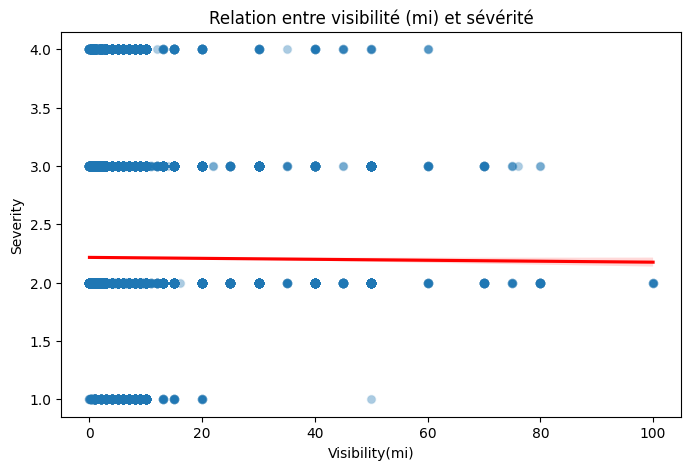

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Visibility(mi)',
    y='Severity',
    alpha=0.3
)
sns.regplot(data=df, x='Visibility(mi)', y='Severity', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Relation entre visibilité (mi) et sévérité")
plt.show()


### Accidents par catégorie de visibilité (BAR PLOT)

Question: Quelle visibilité est la plus dangereuse ?

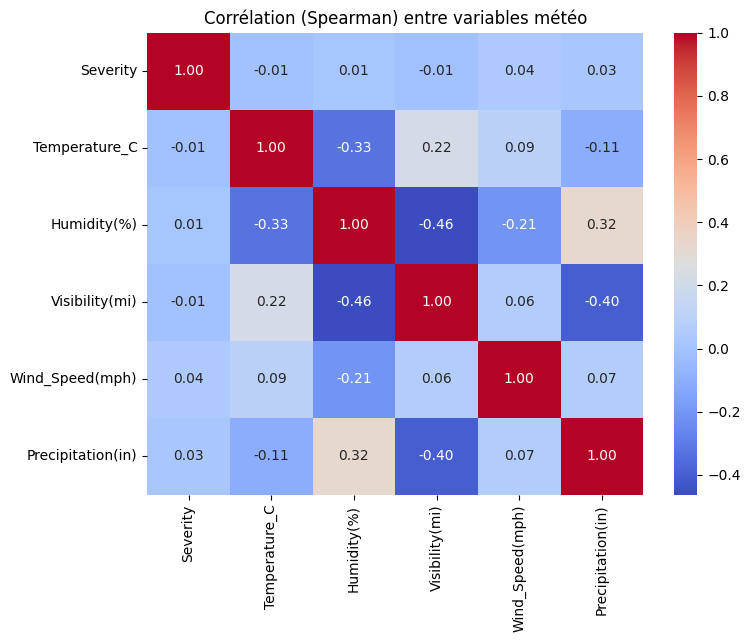

In [23]:
meteo_cols = [
    'Severity',
    'Temperature_C',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)'
]
df_meteo = df[meteo_cols].dropna()
corr = df_meteo.corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Corrélation (Spearman) entre variables météo")
plt.show()

### Nombre d’accidents par Weather_Condition

Question: Quelles conditions météo génèrent le plus d’accidents?

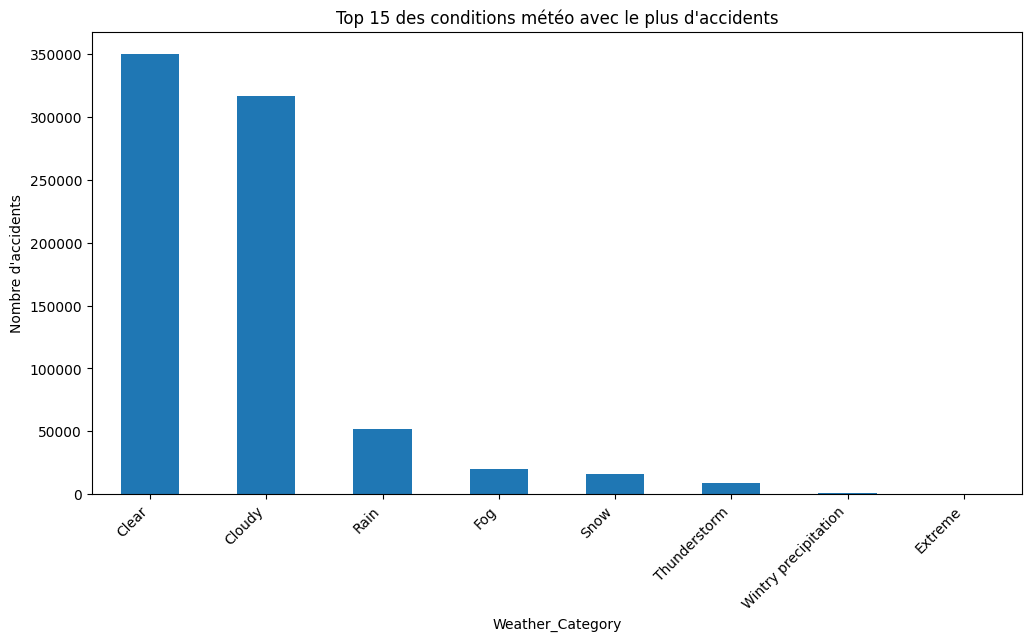

In [24]:
acc_weather = (
    df_filtered['Weather_Category']
    .value_counts()
    .head(15)  # top 15 pour lisibilité
)

plt.figure(figsize=(12,6))
acc_weather.plot(kind='bar')
plt.title("Top 15 des conditions météo avec le plus d'accidents")
plt.xlabel("Weather_Category")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45, ha='right')
plt.show()